# ERTNet – EEG Valence Classification on DEAP


## 1 · Install dependencies

In [1]:
!pip install -q kaggle captum
print("Dependencies installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 17.7 MB/s eta 0:00:00
Dependencies installed.


## 2 · Download DEAP Dataset

In [2]:
import os, json
from google.colab import files

AUTH_METHOD = "upload"
KAGGLE_USERNAME = "your_kaggle_username"
KAGGLE_KEY      = "your_kaggle_key"

if AUTH_METHOD == "upload":
    print("Please upload your kaggle.json file:")
    uploaded = files.upload()
    os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
    with open(os.path.expanduser("~/.kaggle/kaggle.json"), "wb") as f:
        f.write(list(uploaded.values())[0])
else:
    os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
    creds = {"username": KAGGLE_USERNAME, "key": KAGGLE_KEY}
    with open(os.path.expanduser("~/.kaggle/kaggle.json"), "w") as f:
        json.dump(creds, f)

os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)
print("Kaggle credentials configured.")

Please upload your kaggle.json file:


Saving kaggle.json to kaggle.json
Kaggle credentials configured.


In [3]:
!kaggle datasets download -d manh123df/deap-dataset -p /content/deap --unzip
import glob
print("Files found:")
for f in sorted(glob.glob("/content/deap/**/*", recursive=True))[:30]:
    print(" ", f)

Dataset URL: https://www.kaggle.com/datasets/manh123df/deap-dataset
License(s): unknown
100% 2.73G/2.73G [01:10<00:00, 41.3MB/s]

Files found:
  /content/deap/deap-dataset
  /content/deap/deap-dataset/EDA_DEAP.ipynb
  /content/deap/deap-dataset/Metadata
  /content/deap/deap-dataset/Metadata/online_ratings.xls
  /content/deap/deap-dataset/Metadata/participant_questionnaire.xls
  /content/deap/deap-dataset/Metadata/participant_ratings.xls
  /content/deap/deap-dataset/Metadata/video_list.xlsx
  /content/deap/deap-dataset/Metadata/video_list_fixed.xlsx
  /content/deap/deap-dataset/audio_stimuli_MIDI
  /content/deap/deap-dataset/audio_stimuli_MIDI/exp_id_1.mid
  /content/deap/deap-dataset/audio_stimuli_MIDI/exp_id_10.mid
  /content/deap/deap-dataset/audio_stimuli_MIDI/exp_id_11.mid
  /content/deap/deap-dataset/audio_stimuli_MIDI/exp_id_12.mid
  /content/deap/deap-dataset/audio_stimuli_MIDI/exp_id_13.mid
  /content/deap/deap-dataset/audio_stimuli_MIDI/exp_id_14.mid
  /content/deap/deap-datas

## 3 · Preprocess DEAP  Files


In [5]:
import pickle, glob, numpy as np

DATA_DIR   = "/content/deap"
N_CHANNELS = 32
N_SAMPLES  = 7680
TRIALS     = 40

X_list, y_list = [], []

dat_files = sorted(glob.glob(f"{DATA_DIR}/**/*.dat", recursive=True) +
                   glob.glob(f"{DATA_DIR}/**/*.pkl", recursive=True))

if not dat_files:
    raise FileNotFoundError(
        "No .dat files found. Check the download path above. Try: glob.glob('/ content/deap/**/*', recursive=True)")

print(f"Found {len(dat_files)} subject files")

for path in dat_files:
    with open(path, "rb") as f:
        subj = pickle.load(f, encoding="latin1")

    eeg  = subj["data"][:, :N_CHANNELS, :N_SAMPLES]
    vals = (subj["labels"][:, 0] > 5).astype(np.int32)

    X_list.append(eeg)
    y_list.append(vals)

X_cnn_input = np.vstack(X_list).astype(np.float32)
y_flat_bin  = np.concatenate(y_list).astype(np.float32)
X_cnn_input = np.nan_to_num(X_cnn_input, nan=0.0)

print(f"X shape : {X_cnn_input.shape}")
print(f"y shape : {y_flat_bin.shape}")
print(f"Class balance  High={y_flat_bin.mean()*100:.1f}%  Low={100-y_flat_bin.mean()*100:.1f}%")

Found 32 subject files
X shape : (1280, 32, 7680)
y shape : (1280,)
Class balance  High=21.0%  Low=79.0%


## 4 · Imports & GPU Setup

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import LeaveOneGroupOut
from captum.attr import IntegratedGradients, FeatureAblation
import matplotlib.pyplot as plt
import seaborn as sns

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

num_subjects = X_cnn_input.shape[0] // TRIALS
groups = np.repeat(np.arange(num_subjects), TRIALS)
logo   = LeaveOneGroupOut()

high_val = (y_flat_bin == 1).sum()
low_val  = (y_flat_bin == 0).sum()
pos_weight_val = torch.tensor([low_val / high_val], dtype=torch.float32).to(DEVICE)
print(f"Class weight (pos): {pos_weight_val.item():.4f}")

Using device: cuda
Class weight (pos): 3.7584


## 5 · ERTNet Model Definition


In [7]:
class ERTNet(nn.Module):
    def __init__(self, in_channels=32):
        super().__init__()
        self.temp_conv    = nn.Conv1d(in_channels, 64, kernel_size=64, padding=31)
        self.bn1          = nn.BatchNorm1d(64)
        self.spatial_conv = nn.Conv1d(64, 64, kernel_size=1)
        self.bn2          = nn.BatchNorm1d(64)
        self.pool         = nn.MaxPool1d(16)
        self.attention    = nn.MultiheadAttention(embed_dim=64, num_heads=4, batch_first=True)
        self.fc           = nn.Linear(64, 1)

    def forward(self, x, return_attention=False):
        x = torch.relu(self.bn1(self.temp_conv(x)))
        x = torch.relu(self.bn2(self.spatial_conv(x)))
        x = self.pool(x)
        x = x.permute(0, 2, 1)
        attn_out, attn_weights = self.attention(x, x, x)
        out    = attn_out.mean(dim=1)
        logits = self.fc(out)
        if return_attention:
            return logits, attn_weights
        return logits


class CaptumWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    def forward(self, x):
        return self.model(x, return_attention=False)


print("ERTNet defined.")
_dummy = torch.zeros(2, 32, 7680).to(DEVICE)
_m     = ERTNet().to(DEVICE)
print("Output shape:", _m(_dummy).shape)

ERTNet defined.
Output shape: torch.Size([2, 1])


## 6 · LOSO Training

In [9]:
MAX_SUBJECTS = None
NUM_EPOCHS   = 15
BATCH_SIZE   = 32

ertnet_results = []
model_ert      = None

for fold, (train_idx, test_idx) in enumerate(
        logo.split(X_cnn_input, y_flat_bin, groups)):

    subject_id = groups[test_idx][0] + 1
    if MAX_SUBJECTS and fold >= MAX_SUBJECTS:
        break

    X_tr = torch.tensor(X_cnn_input[train_idx], dtype=torch.float32)
    y_tr = torch.tensor(y_flat_bin[train_idx],  dtype=torch.float32).unsqueeze(1)
    loader = DataLoader(TensorDataset(X_tr, y_tr),
                        batch_size=BATCH_SIZE, shuffle=True)

    model_ert = ERTNet().to(DEVICE)
    optimiser = optim.Adam(model_ert.parameters(), lr=0.0005)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_val)

    model_ert.train()
    for epoch in range(NUM_EPOCHS):
        for bX, by in loader:
            bX, by = bX.to(DEVICE), by.to(DEVICE)
            optimiser.zero_grad()
            loss = criterion(model_ert(bX), by)
            loss.backward()
            optimiser.step()

    model_ert.eval()
    with torch.no_grad():
        X_te = torch.tensor(X_cnn_input[test_idx], dtype=torch.float32).to(DEVICE)
        y_te = torch.tensor(y_flat_bin[test_idx],  dtype=torch.float32).unsqueeze(1).to(DEVICE)
        preds = (torch.sigmoid(model_ert(X_te)) > 0.5).float()
        acc   = (preds == y_te).float().mean().item()

    print(f"Subject {subject_id:2d} | Acc: {acc*100:.2f}%")
    ertnet_results.append({"Subject": subject_id, "Accuracy": acc})

avg_acc = np.mean([r["Accuracy"] for r in ertnet_results])
print(f"Mean LOSO Accuracy: {avg_acc*100:.2f}%")

Subject  1 | Acc: 15.00%
Subject  2 | Acc: 85.00%
Subject  3 | Acc: 42.50%
Subject  4 | Acc: 90.00%
Subject  5 | Acc: 27.50%
Subject  6 | Acc: 57.50%
Subject  7 | Acc: 25.00%
Subject  8 | Acc: 50.00%
Subject  9 | Acc: 87.50%
Subject 10 | Acc: 70.00%
Subject 11 | Acc: 62.50%
Subject 12 | Acc: 95.00%
Subject 13 | Acc: 95.00%
Subject 14 | Acc: 80.00%
Subject 15 | Acc: 70.00%
Subject 16 | Acc: 20.00%
Subject 17 | Acc: 22.50%
Subject 18 | Acc: 82.50%
Subject 19 | Acc: 87.50%
Subject 20 | Acc: 15.00%
Subject 21 | Acc: 62.50%
Subject 22 | Acc: 75.00%
Subject 23 | Acc: 40.00%
Subject 24 | Acc: 60.00%
Subject 25 | Acc: 12.50%
Subject 26 | Acc: 75.00%
Subject 27 | Acc: 37.50%
Subject 28 | Acc: 25.00%
Subject 29 | Acc: 15.00%
Subject 30 | Acc: 25.00%
Subject 31 | Acc: 60.00%
Subject 32 | Acc: 75.00%
Mean LOSO Accuracy: 54.45%


## 7 · Per-Subject Accuracy Plot

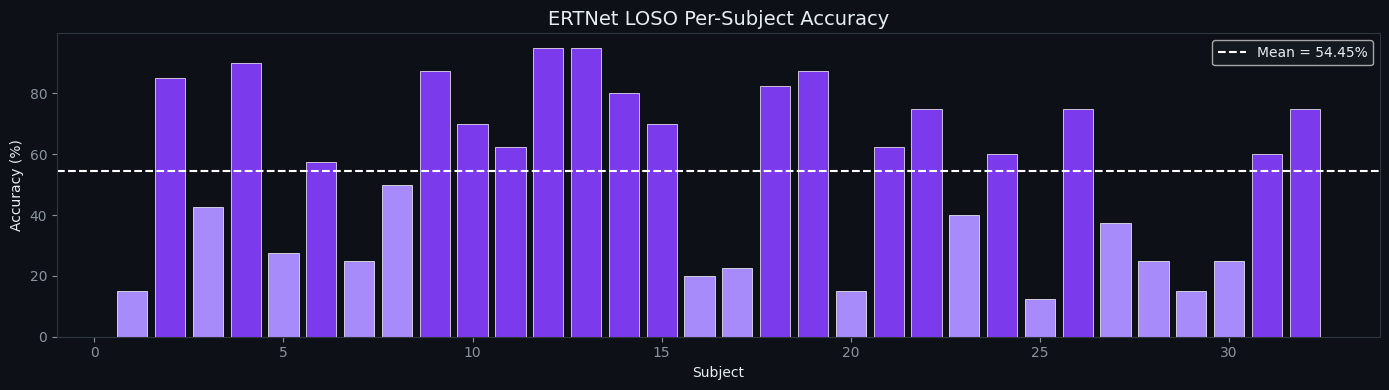

In [10]:
subjects = [r["Subject"]  for r in ertnet_results]
accs     = [r["Accuracy"] for r in ertnet_results]

fig, ax = plt.subplots(figsize=(14, 4))
colors  = ["#7C3AED" if a >= avg_acc else "#A78BFA" for a in accs]
ax.bar(subjects, [a*100 for a in accs], color=colors, edgecolor="white", linewidth=0.5)
ax.axhline(avg_acc*100, color="white", linestyle="--", linewidth=1.5,
           label=f"Mean = {avg_acc*100:.2f}%")
ax.set_facecolor("#0D1117"); fig.patch.set_facecolor("#0D1117")
ax.tick_params(colors="#8B949E"); ax.spines[:].set_color("#30363D")
ax.set_xlabel("Subject", color="#E6EDF3")
ax.set_ylabel("Accuracy (%)", color="#E6EDF3")
ax.set_title("ERTNet LOSO Per-Subject Accuracy", color="#E6EDF3", fontsize=14)
ax.legend(facecolor="#161B22", labelcolor="#E6EDF3")
plt.tight_layout(); plt.show()

## 8 · Explainability (4 XAI Methods)


In [11]:
assert model_ert is not None, "Run the training cell first!"

DEAP_CHANNELS = [
    "Fp1","AF3","F3","F7","FC5","FC1","C3","T7",
    "CP5","CP1","P3","P7","PO3","O1","Oz","Pz",
    "Fp2","AF4","Fz","F4","F8","FC6","FC2","C4",
    "T8","CP6","CP2","P4","P8","PO4","O2","Cz"
]
XAI_SAMPLES = 5

model_ert.eval()
sample_input = torch.tensor(
    X_cnn_input[:XAI_SAMPLES], dtype=torch.float32
).to(DEVICE).requires_grad_(True)

print("Sample input shape:", sample_input.shape)

Sample input shape: torch.Size([5, 32, 7680])


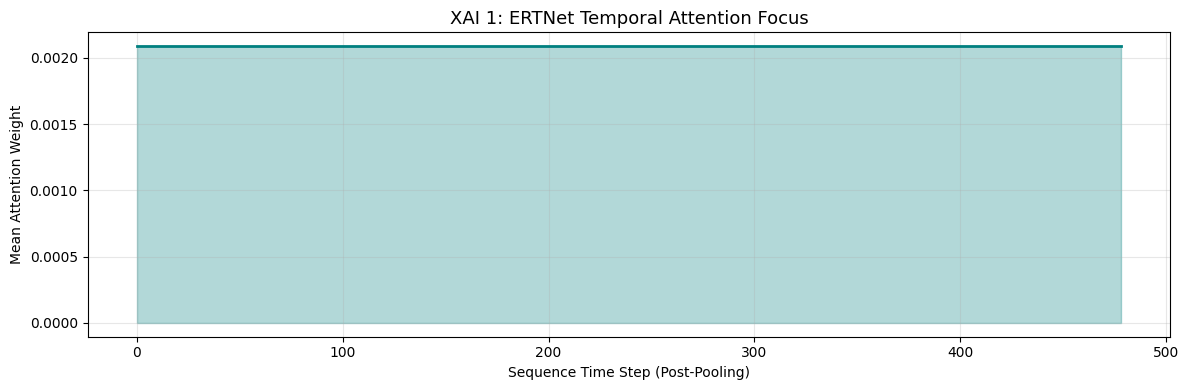

Peak attention step: 23


In [12]:
with torch.no_grad():
    _, attn_weights = model_ert(sample_input.detach(), return_attention=True)

avg_attn = attn_weights.mean(dim=0).cpu().numpy()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(avg_attn.mean(axis=1), color="teal", linewidth=2)
ax.fill_between(range(len(avg_attn)), avg_attn.mean(axis=1), alpha=0.3, color="teal")
ax.set_title("XAI 1: ERTNet Temporal Attention Focus", fontsize=13)
ax.set_xlabel("Sequence Time Step (Post-Pooling)")
ax.set_ylabel("Mean Attention Weight")
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print("Peak attention step:", int(avg_attn.mean(axis=1).argmax()))

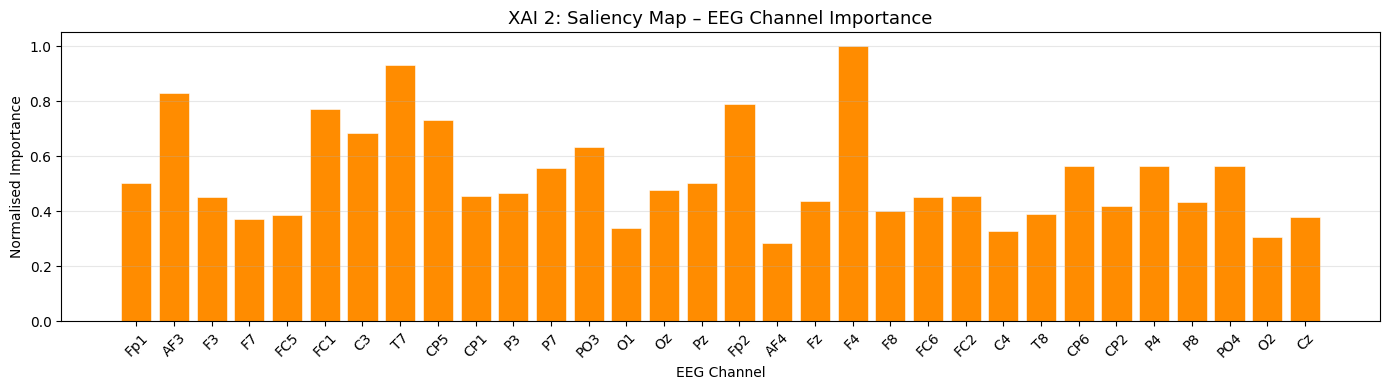

In [14]:
si = torch.tensor(X_cnn_input[:XAI_SAMPLES], dtype=torch.float32,
                  requires_grad=True).to(DEVICE)
si.retain_grad()
model_ert.zero_grad()
out = model_ert(si)
out.sum().backward()
saliency_attr = si.grad.abs().mean(dim=(0, 2)).cpu().detach().numpy()
saliency_attr /= saliency_attr.max()

fig, ax = plt.subplots(figsize=(14, 4))
bars = ax.bar(DEAP_CHANNELS, saliency_attr, color="darkorange", edgecolor="white", linewidth=0.4)
ax.set_title("XAI 2: Saliency Map – EEG Channel Importance", fontsize=13)
ax.set_xlabel("EEG Channel"); ax.set_ylabel("Normalised Importance")
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

IG done.
Ablation done.


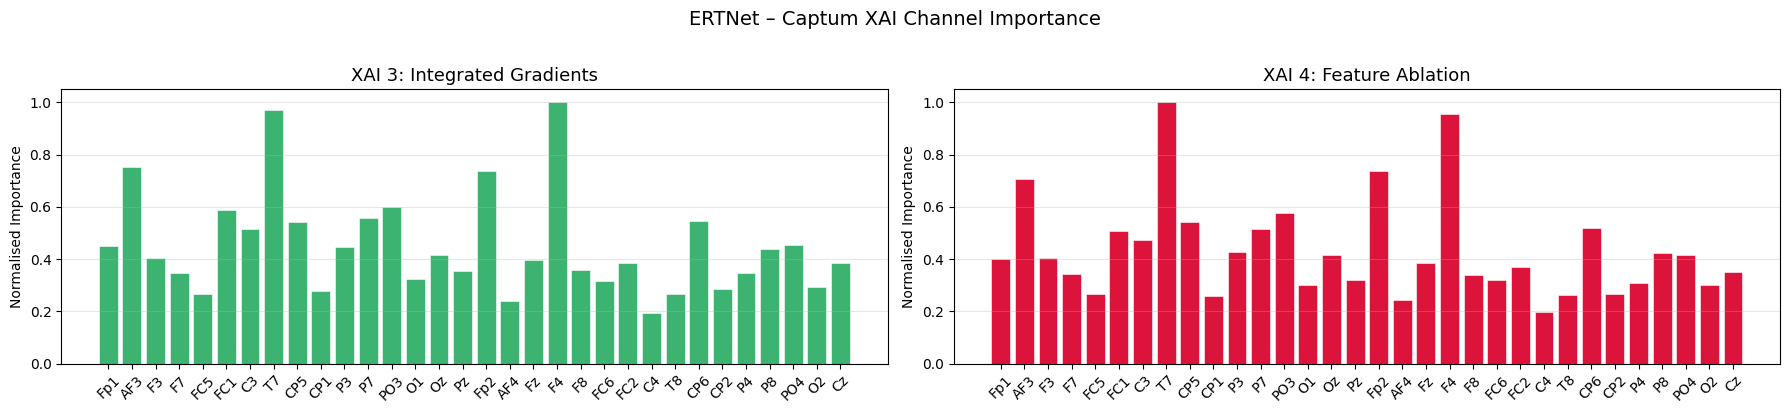

In [15]:
torch.backends.cudnn.enabled = False

wrapped  = CaptumWrapper(model_ert).to(DEVICE)
si_cap   = torch.tensor(X_cnn_input[:XAI_SAMPLES], dtype=torch.float32,
                         requires_grad=True).to(DEVICE)

ig       = IntegratedGradients(wrapped)
ig_attr  = ig.attribute(si_cap, target=0)
ig_ch    = ig_attr.abs().mean(dim=(0, 2)).cpu().detach().numpy()
ig_ch   /= ig_ch.max()
print("IG done.")

ablator  = FeatureAblation(wrapped)
abl_attr = ablator.attribute(si_cap, target=0)
abl_ch   = abl_attr.abs().mean(dim=(0, 2)).cpu().detach().numpy()
abl_ch  /= abl_ch.max()
print("Ablation done.")

torch.backends.cudnn.enabled = True

fig, axes = plt.subplots(1, 2, figsize=(18, 4))

axes[0].bar(DEAP_CHANNELS, ig_ch, color="mediumseagreen", edgecolor="white", linewidth=0.4)
axes[0].set_title("XAI 3: Integrated Gradients", fontsize=13)
axes[0].set_ylabel("Normalised Importance")
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(DEAP_CHANNELS, abl_ch, color="crimson", edgecolor="white", linewidth=0.4)
axes[1].set_title("XAI 4: Feature Ablation", fontsize=13)
axes[1].set_ylabel("Normalised Importance")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(axis="y", alpha=0.3)

plt.suptitle("ERTNet – Captum XAI Channel Importance", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

## 9 · XAI Summary – Channel Importance Comparison

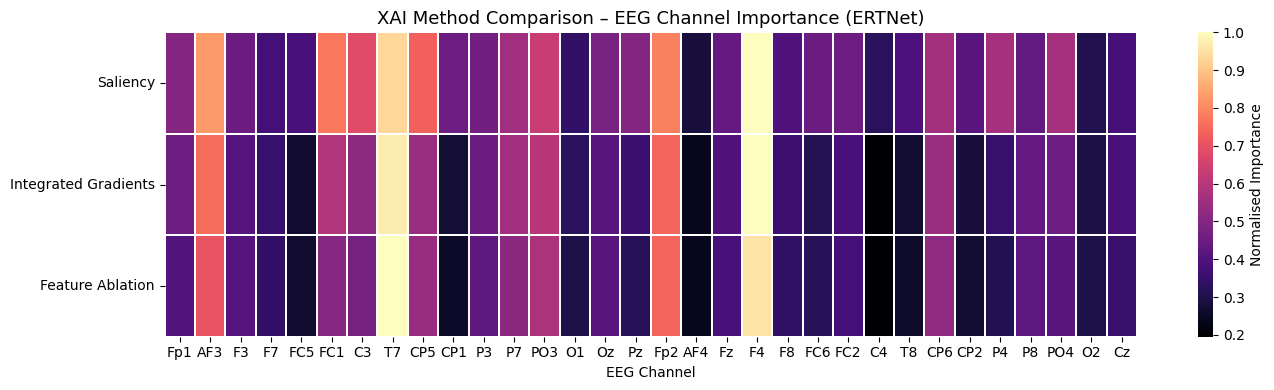

Top-5 channels per XAI method:
  Saliency                 : ['F4', 'T7', 'AF3', 'Fp2', 'FC1']
  Integrated Gradients     : ['F4', 'T7', 'AF3', 'Fp2', 'PO3']
  Feature Ablation         : ['T7', 'F4', 'Fp2', 'AF3', 'PO3']


In [17]:
import pandas as pd

xai_df = pd.DataFrame({
    "Saliency":            saliency_attr,
    "Integrated Gradients": ig_ch,
    "Feature Ablation":    abl_ch,
}, index=DEAP_CHANNELS)

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(xai_df.T, cmap="magma", linewidths=0.3,
            ax=ax, cbar_kws={"label": "Normalised Importance"})
ax.set_title("XAI Method Comparison – EEG Channel Importance (ERTNet)", fontsize=13)
ax.set_xlabel("EEG Channel")
plt.tight_layout(); plt.show()

print("Top-5 channels per XAI method:")
for col in xai_df.columns:
    top5 = xai_df[col].nlargest(5).index.tolist()
    print(f"  {col:25s}: {top5}")

## 10 · Save Results & Download


In [18]:
import pandas as pd

df = pd.DataFrame(ertnet_results)
df.to_csv("/content/ertnet_results.csv", index=False)
print(df.to_string(index=False))
print(f"Saved ertnet_results.csv")

torch.save(model_ert.state_dict(), "/content/ertnet_weights.pt")
print("Saved ertnet_weights.pt")

from google.colab import files
files.download("/content/ertnet_results.csv")
files.download("/content/ertnet_weights.pt")

 Subject  Accuracy
       1     0.150
       2     0.850
       3     0.425
       4     0.900
       5     0.275
       6     0.575
       7     0.250
       8     0.500
       9     0.875
      10     0.700
      11     0.625
      12     0.950
      13     0.950
      14     0.800
      15     0.700
      16     0.200
      17     0.225
      18     0.825
      19     0.875
      20     0.150
      21     0.625
      22     0.750
      23     0.400
      24     0.600
      25     0.125
      26     0.750
      27     0.375
      28     0.250
      29     0.150
      30     0.250
      31     0.600
      32     0.750
Saved ertnet_results.csv
Saved ertnet_weights.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>